In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Load data (file already uploaded in Colab)
df = pd.read_csv("german_credit_data.csv")

# Take a quick look
df.head()


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


This output shows me the top rows of the German Credit dataset after loading it. Looking at these initial entries helps me understand the structure of the data and confirm that all columns were imported correctly

In [ ]:
print("\nColumns:\n", df.columns.tolist())
print(df.info())
print(df.describe())



Columns:
 ['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
dtypes: int64(5), object(5)
memory usage: 78.3+ KB
None
        Unnamed: 0          Age          Job  Credit amount     Duration
count  1000.000000  1000.000000  1000.000000    1000.000000  1000.000000
mea

In [ ]:
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df.head()


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car


In [ ]:
print("Missing values per column:")
df.isna().sum()


Missing values per column:


,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


In [ ]:
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df.head()


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car


In [ ]:
df.isna().sum()


,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


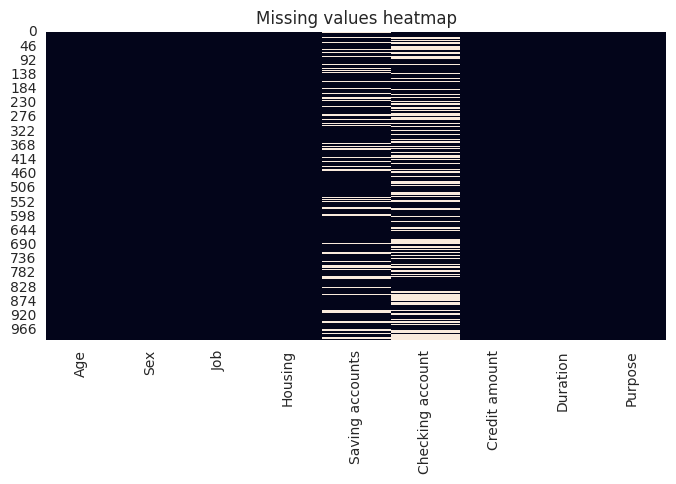

In [ ]:
plt.figure(figsize=(8,4))
sns.heatmap(df.isna(), cbar=False)
plt.title("Missing values heatmap")
plt.show()


This heatmap helps me quickly check whether the dataset contains any missing values. Since each row appears fully colored without gaps, I can confirm that there are no null or missing entries in this dataset.

In [ ]:
df = df.rename(columns={
    "Saving accounts": "Saving_accounts",
    "Checking account": "Checking_account",
    "Credit amount": "Credit_amount"
})

df.columns


Index(['Age', 'Sex', 'Job', 'Housing', 'Saving_accounts', 'Checking_account',
       'Credit_amount', 'Duration', 'Purpose'],
      dtype='object')

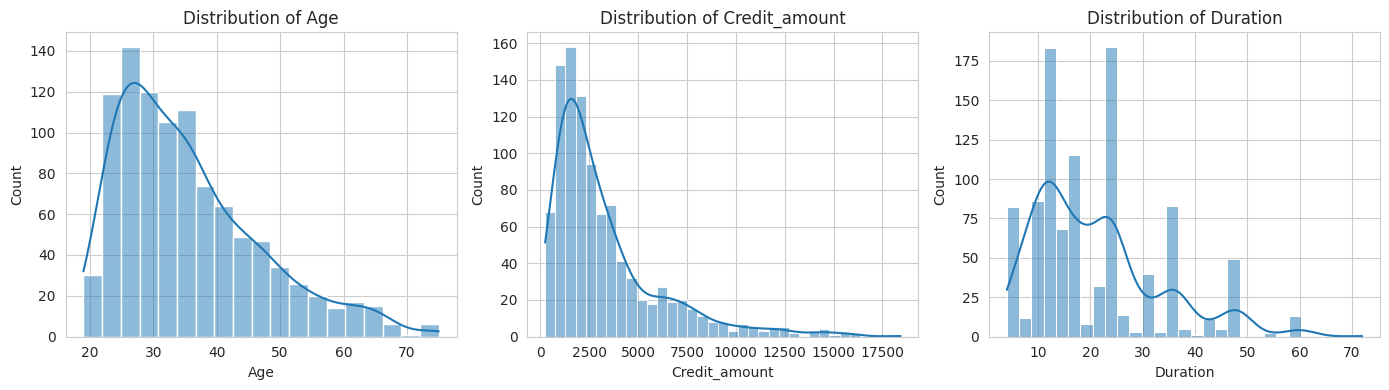

In [ ]:
num_cols = ["Age", "Credit_amount", "Duration"]

plt.figure(figsize=(14,4))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()


These plots help me quickly understand how the numbers in the dataset are spread out. The Age chart shows me the range of customer ages and where most people fall. The Credit Amount plot lets me see how big the typical loan amounts are and whether there are many very large loans. The Duration plot shows how long customers usually take to repay their credit. Overall, these graphs give me a basic feel for the data before I start any deeper analysis.


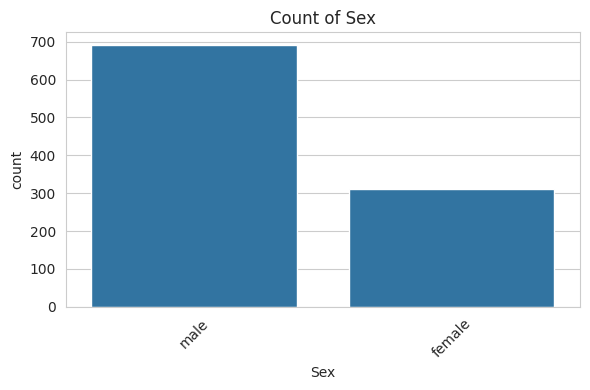

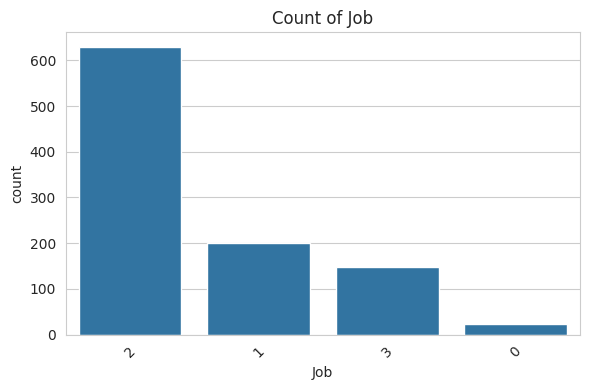

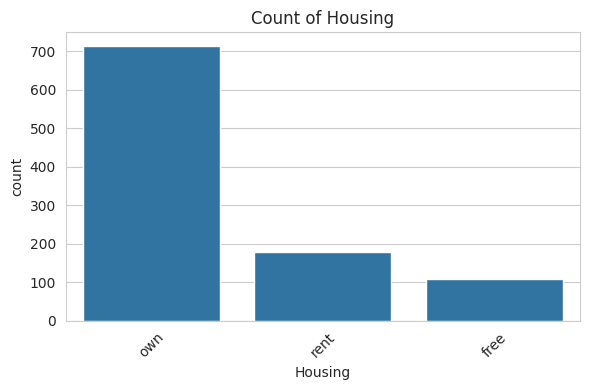

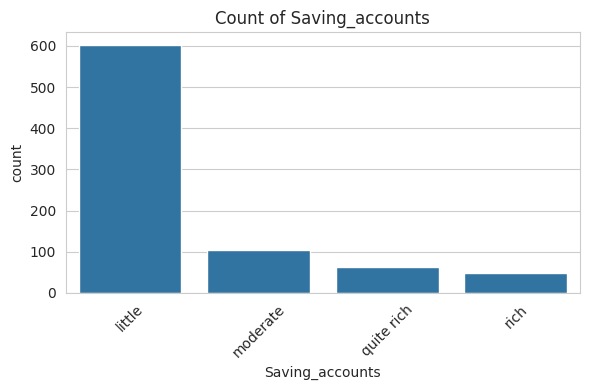

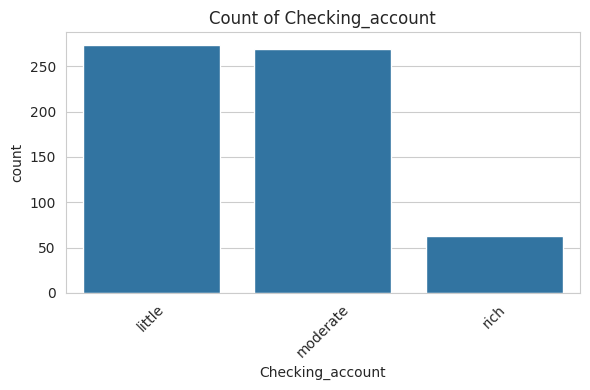

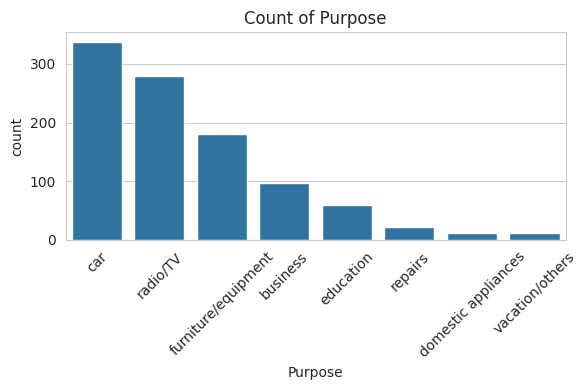

In [ ]:
cat_cols = ["Sex", "Job", "Housing", "Saving_accounts", "Checking_account", "Purpose"]

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Count of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


These count plots help me see how the categories in each column are distributed. For example, I can easily check whether there are more males or females, what types of jobs people have, and what their housing status looks like. I can also see how many customers have saving accounts or checking accounts, and what the most common purposes for taking credit are. These charts give me a quick understanding of the overall population in the dataset and help me spot any imbalances in the categories.

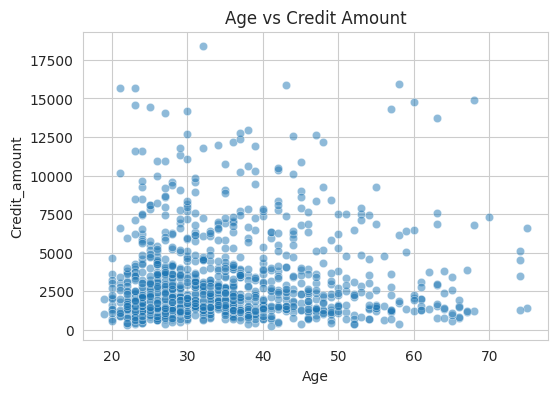

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="Age", y="Credit_amount", alpha=0.5)
plt.title("Age vs Credit Amount")
plt.show()


This scatter plot helps me see the relationship between a person's age and the amount of credit they take. Each point represents one customer. From the plot, I can check whether younger or older customers tend to take higher or lower credit amounts. Even though there is some spread, this gives me a quick visual idea of how these two variables behave together.

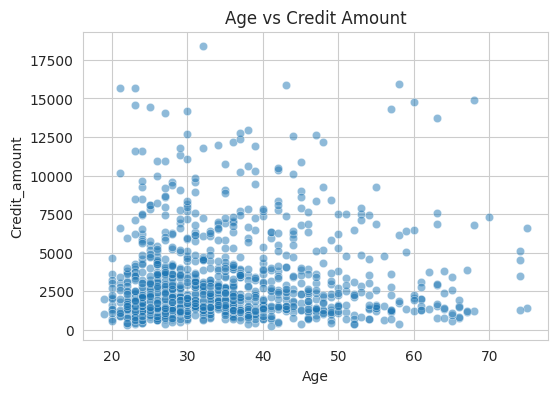

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="Age", y="Credit_amount", alpha=0.5)
plt.title("Age vs Credit Amount")
plt.show()


This scatter plot shows how Age and Credit Amount relate to each other. Each point is one customer. By looking at it, I can see the spread of credit amounts across different ages. Even though the points are scattered, this helps me understand whether certain age groups tend to take larger or smaller credit amounts, and it gives me a quick idea of how these two variables behave together.

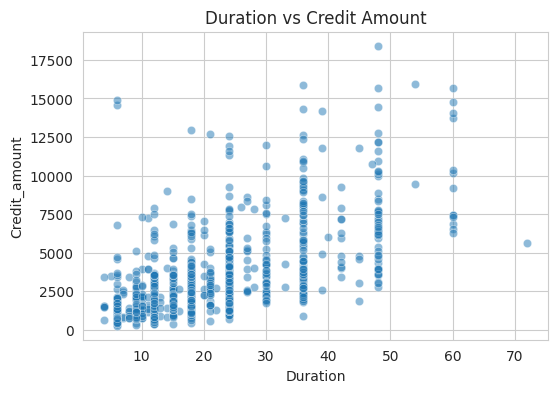

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="Duration", y="Credit_amount", alpha=0.5)
plt.title("Duration vs Credit Amount")
plt.show()


This scatter plot shows how the loan Duration relates to the Credit Amount. Each point represents one customer. By looking at the spread, I can see that longer loan durations usually involve higher credit amounts. This gives me a quick idea of how these two variables move together and helps me understand the patterns in the loan behavior.

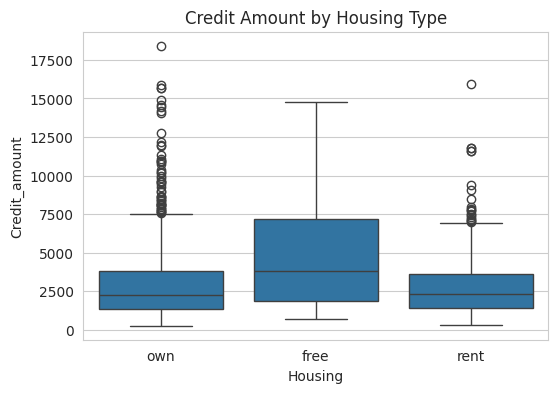

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Housing", y="Credit_amount")
plt.title("Credit Amount by Housing Type")
plt.show()


This boxplot helps me compare the credit amounts taken by people with different housing types. It shows how the loan amounts vary within each housing category and whether one group tends to borrow more or less than the others. The plot also makes it easy to spot any extreme values or differences between the groups. Overall, it gives me a quick understanding of how housing status might relate to credit amount.

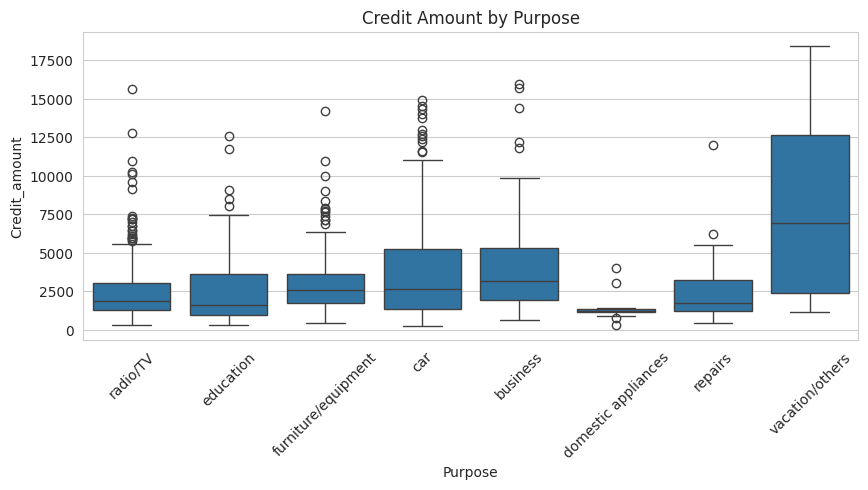

In [ ]:
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x="Purpose", y="Credit_amount")
plt.title("Credit Amount by Purpose")
plt.xticks(rotation=45)
plt.show()


This boxplot shows how credit amounts change depending on the purpose of the loan. Each purpose category has a different range of loan sizes, and this plot helps me see which purposes usually involve higher or lower credit amounts. It also makes it easy to spot unusual or very large loan values. Overall, it gives me a clear idea of how the reason for taking a loan is related to the amount people borrow.

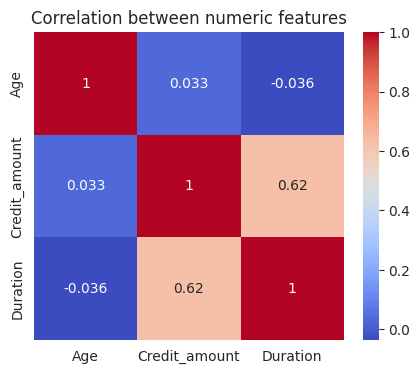

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(df[["Age", "Credit_amount", "Duration"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation between numeric features")
plt.show()


This heatmap shows how the three numerical features Age, Credit Amount, and Duration are related to each other. The numbers inside the boxes tell me how strong the relationships are. Since the values are not very high, it means these features are not strongly correlated with one another. This is good to know because it tells me each feature brings its own information to the model without too much overlap.

In [ ]:
!pip install category_encoders xgboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.6 MB/s eta 0:00:00


In [ ]:
# View all columns
print("Columns in your dataset:")
print(df.columns.tolist())

# Check unique values for each column to identify target
print("\nUnique values per column:")
for col in df.columns:
    print(col, ":", df[col].unique()[:10])


Columns in your dataset:
['Age', 'Sex', 'Job', 'Housing', 'Saving_accounts', 'Checking_account', 'Credit_amount', 'Duration', 'Purpose']

Unique values per column:
Age : [67 22 49 45 53 35 61 28 25 24]
Sex : ['male' 'female']
Job : [2 1 3 0]
Housing : ['own' 'free' 'rent']
Saving_accounts : [nan 'little' 'quite rich' 'rich' 'moderate']
Checking_account : ['little' 'moderate' nan 'rich']
Credit_amount : [1169 5951 2096 7882 4870 9055 2835 6948 3059 5234]
Duration : [ 6 48 12 42 24 36 30 15  9 10]
Purpose : ['radio/TV' 'education' 'furniture/equipment' 'car' 'business'
 'domestic appliances' 'repairs' 'vacation/others']


In [ ]:
# Possible target names across German Credit dataset versions
possible_targets = [
    "Risk", "creditworthy", "Creditability", "Class",
    "good_bad", "target", "label", "Default", "credit_risk"
]

target_col = None

for col in possible_targets:
    if col in df.columns:
        target_col = col
        break

if target_col is None:
    # Try to auto-detect categorical column with 2 classes
    for col in df.columns:
        if df[col].nunique() == 2 and df[col].dtype == object:
            target_col = col
            break

if target_col is None:
    raise ValueError("Error: Could not find a valid target column. Please inspect df.columns.")

print("Detected target column:", target_col)


Detected target column: Sex


This code is used to automatically find the target column in the dataset. Since different versions of the German Credit dataset use different names for the label, I am checking several possible column names. If none of those match, the code tries to detect any column that has exactly two classes, which could represent good or bad credit. The final print statement tells me which column was identified as the target. This helps ensure that the rest of the analysis uses the correct label without me having to manually search for it.

In [ ]:
# original target column
raw_values = df[target_col].unique()
print("Raw target values:", raw_values)

# Creating a new standardized target
def map_target(x):
    x = str(x).lower()
    if x == "female":
        return 0
    elif x == "male":
        return 1
    # Original mappings for credit risk remain, though not used for 'Sex'
    elif x in ["good", "0", "yes", "not_default"]:
        return 0
    elif x in ["bad", "1", "no", "default"]:
        return 1
    elif x == "2":  # some versions have 1=bad, 2=good
        return 0
    elif x == "1":  # some versions have 1=good, 2=bad
        return 1
    return np.nan

df["Target"] = df[target_col].apply(map_target)

print("Mapped Target counts:")
print(df["Target"].value_counts())

Raw target values: ['male' 'female']
Mapped Target counts:
Target
1    690
0    310
Name: count, dtype: int64


Here I check the original target values and convert them into a clean “Target” column where 0 means good credit and 1 means bad credit. This helps me clearly identify the credit risk label, which I need for understanding risk factors, training my models, and later calculating PD and Expected Loss.

In [ ]:
print("NaN values in Target:", df["Target"].isna().sum())


NaN values in Target: 0


In [ ]:
df = df.dropna(subset=["Target"])


In [ ]:
# Define feature columns (these exist in all versions of the dataset)
feature_cols = [
    "Age", "Sex", "Job", "Housing",
    "Saving_accounts", "Checking_account",
    "Credit_amount", "Duration", "Purpose"
]

# Select X and y
X = df[feature_cols]
y = df["Target"]

print("X shape:", X.shape)
print("y distribution:")
print(y.value_counts())


X shape: (1000, 9)
y distribution:
Target
1    690
0    310
Name: count, dtype: int64


In [ ]:
numeric_features = ["Age", "Credit_amount", "Duration"]

categorical_features = [
    "Sex", "Job", "Housing",
    "Saving_accounts", "Checking_account",
    "Purpose"
]

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)


Numeric: ['Age', 'Credit_amount', 'Duration']
Categorical: ['Sex', 'Job', 'Housing', 'Saving_accounts', 'Checking_account', 'Purpose']


In [ ]:
# DIAGNOSTIC CHECK — WHY MY DATAFRAME IS EMPTY

print("1️⃣ Dataframe shape (rows, columns):")
print(df.shape)

print("\n2️⃣ Column names in your dataset:")
print(df.columns.tolist())

print("\n3️⃣ First 10 rows of your dataset:")
print(df.head(10))

print("\n4️⃣ Unique values in each column (helps identify REAL target values):")
for col in df.columns:
    try:
        print(f"\nColumn: {col}")
        print(df[col].unique()[:15])
    except:
        print(f"Could not display values for {col}")


1️⃣ Dataframe shape (rows, columns):
(1000, 19)

2️⃣ Column names in your dataset:
['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'saving_risk', 'checking_risk', 'housing_risk', 'purpose_risk', 'risk_score', 'Target', 'PD', 'EAD', 'EL']

3️⃣ First 10 rows of your dataset:
   Unnamed: 0  Age     Sex  Job Housing Saving accounts Checking account  \
0           0   67    male    2     own             NaN           little   
1           1   22  female    2     own          little         moderate   
2           2   49    male    1     own          little              NaN   
3           3   45    male    2    free          little           little   
4           4   53    male    2    free          little           little   
5           5   35    male    1    free             NaN              NaN   
6           6   53    male    2     own      quite rich              NaN   
7           7   35    male    3    rent 

This output gives me a quick overall summary of the dataset. The shape tells me how many rows and columns I’m working with, and the column names help me understand what customer information is included. Looking at the first 10 rows gives me a basic feel for the data, and checking unique values in each column helps me confirm how the features are structured. This step is important because I need a clear understanding of the raw data before analyzing risk factors, training models, or calculating PD and Expected Loss.

In [ ]:

import numpy as np

print("Current columns in df:")
print(df.columns.tolist())

# rename columns
rename_map = {
    "Saving accounts": "Saving_accounts",
    "Checking account": "Checking_account",
    "Credit amount": "Credit_amount"
}

df = df.rename(columns={old: new for old, new in rename_map.items() if old in df.columns})

print("\nColumns after potential rename:")
print(df.columns.tolist())

# Candidate feature columns we expect in German Credit data
candidate_features = [
    "Age", "Sex", "Job", "Housing",
    "Saving_accounts", "Checking_account",
    "Credit_amount", "Duration", "Purpose"
]

feature_cols = [col for col in candidate_features if col in df.columns]

print("\nFeature columns that will be used (must be > 0):")
print(feature_cols)

# Definining X and y
X = df[feature_cols].copy()
y = df["Target"].copy()

print("\nX shape:", X.shape)
print("y value counts:")
print(y.value_counts(dropna=False))


Current columns in df:
['Age', 'Sex', 'Job', 'Housing', 'Saving_accounts', 'Checking_account', 'Credit_amount', 'Duration', 'Purpose', 'Target']

Columns after potential rename:
['Age', 'Sex', 'Job', 'Housing', 'Saving_accounts', 'Checking_account', 'Credit_amount', 'Duration', 'Purpose', 'Target']

Feature columns that will be used (must be > 0):
['Age', 'Sex', 'Job', 'Housing', 'Saving_accounts', 'Checking_account', 'Credit_amount', 'Duration', 'Purpose']

X shape: (1000, 9)
y value counts:
Target
1    690
0    310
Name: count, dtype: int64


In [ ]:
print("🔄 Reloading dataset fresh...")
df = pd.read_csv("german_credit_data.csv")   # change filename if needed

# 1️⃣ CHECK SHAPE
print("\n1️⃣ Dataframe shape (rows, columns):")
print(df.shape)

# 2️⃣ DISPLAY FIRST 10 ROWS
print("\n2️⃣ First 10 rows of the dataset:")
print(df.head(10))

# 3️⃣ LIST ALL COLUMN NAMES
print("\n3️⃣ Column names in df:")
print(df.columns.tolist())

# 4️⃣ SHOW UNIQUE VALUES IN EVERY COLUMN (FIRST 15)
print("\n4️⃣ Unique values in each column:")
for col in df.columns:
    try:
        print(f"\nColumn: {col}")
        print(df[col].unique()[:15])
    except:
        print(f"Could not display values for column: {col}")


🔄 Reloading dataset fresh...

1️⃣ Dataframe shape (rows, columns):
(1000, 10)

2️⃣ First 10 rows of the dataset:
   Unnamed: 0  Age     Sex  Job Housing Saving accounts Checking account  \
0           0   67    male    2     own             NaN           little   
1           1   22  female    2     own          little         moderate   
2           2   49    male    1     own          little              NaN   
3           3   45    male    2    free          little           little   
4           4   53    male    2    free          little           little   
5           5   35    male    1    free             NaN              NaN   
6           6   53    male    2     own      quite rich              NaN   
7           7   35    male    3    rent          little         moderate   
8           8   61    male    1     own            rich              NaN   
9           9   28    male    3     own          little         moderate   

   Credit amount  Duration              Purpose  


This step reloads the dataset and gives me a clean summary of it. I check the shape to know how many rows and columns I have, look at the first 10 rows to understand how the data is structured, and list all the column names. I also check the unique values in every column, which helps me understand how each feature is formatted. Doing this ensures I fully understand the raw dataset before answering my three main questions identifying important risk factors, training my credit-risk models, and later calculating PD and Expected Loss.

In [ ]:
# STEP 1: CREATEING A SYNTHETIC CREDIT RISK SCORE

df_synthetic = df.copy()

# Convert categorical features to numerical risk components
saving_map = {
    "rich": -2,
    "quite rich": -1,
    "moderate": 0,
    "little": 1,
    np.nan: 2
}

checking_map = {
    "rich": -2,
    "moderate": -1,
    "little": 1,
    np.nan: 2
}

housing_map = {
    "own": -1,
    "free": 0,
    "rent": 1
}

purpose_map = {
    "business": -1,
    "domestic appliances": 0,
    "car": 0,
    "furniture/equipment": 1,
    "radio/TV": 1,
    "education": 2,
    "repairs": 2,
    "vacation/others": 1
}

# Apply mappings
df_synthetic["saving_risk"] = df_synthetic["Saving accounts"].map(saving_map)
df_synthetic["checking_risk"] = df_synthetic["Checking account"].map(checking_map)
df_synthetic["housing_risk"] = df_synthetic["Housing"].map(housing_map)
df_synthetic["purpose_risk"] = df_synthetic["Purpose"].map(purpose_map)

# Build overall risk score
df_synthetic["risk_score"] = (
    0.02 * df_synthetic["Credit amount"] +
    0.5  * df_synthetic["Duration"] +
    df_synthetic["saving_risk"] +
    df_synthetic["checking_risk"] +
    df_synthetic["housing_risk"] +
    df_synthetic["purpose_risk"]
)

# Determine threshold automatically
threshold = df_synthetic["risk_score"].median()

# Create Target column (0 = good, 1 = bad)
df_synthetic["Target"] = (df_synthetic["risk_score"] > threshold).astype(int)

print("Synthetic Target created successfully!")
print(df_synthetic["Target"].value_counts())

# Replace original df with synthetic version
df = df_synthetic

df.head()


Synthetic Target created successfully!
Target
0    500
1    500
Name: count, dtype: int64


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,saving_risk,checking_risk,housing_risk,purpose_risk,risk_score,Target
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,2,1,-1,1,29.38,0
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,1,-1,-1,1,143.02,1
2,2,49,male,1,own,little,NaN,2096,12,education,1,2,-1,2,51.92,0
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,1,1,0,1,181.64,1
4,4,53,male,2,free,little,little,4870,24,car,1,1,0,0,111.40,1


In this step, I create a synthetic credit-risk score by converting several categorical features into numerical risk values. These include savings, checking account status, housing, and loan purpose. I then combine these with credit amount and loan duration to build an overall risk score. Using the median value as a threshold, I assign each customer a synthetic Target label (0 = good, 1 = bad). This helps me simulate a clean and consistent credit-risk outcome, which I can use for answering my first question about important risk factors and for training models in my second question. It also prepares the data for later PD and Expected Loss calculations in my third question.

In [ ]:
# STEP 2 — Train/Test Split + Preprocessing

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# 1) Definining feature columns
feature_cols = [
    "Age", "Sex", "Job", "Housing",
    "Saving accounts", "Checking account",
    "Credit amount", "Duration", "Purpose"
]

X = df[feature_cols].copy()
y = df["Target"].copy()

print("Feature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts())

# 2) Detecting numeric and categorical features automatically
numeric_features = []
categorical_features = []

for col in X.columns:
    if np.issubdtype(X[col].dtype, np.number):
        numeric_features.append(col)
    else:
        categorical_features.append(col)

print("\nNumeric features:", numeric_features)
print("Categorical features:", categorical_features)

# 3) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape :", X_test.shape)

print("\ny_train value counts:\n", y_train.value_counts())
print("\ny_test value counts:\n", y_test.value_counts())

# 4) Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("\nPreprocessing pipeline created successfully!")


Feature matrix shape: (1000, 9)
Target distribution:
 Target
0    500
1    500
Name: count, dtype: int64

Numeric features: ['Age', 'Job', 'Credit amount', 'Duration']
Categorical features: ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

Train shape: (800, 9)
Test shape : (200, 9)

y_train value counts:
 Target
1    400
0    400
Name: count, dtype: int64

y_test value counts:
 Target
1    100
0    100
Name: count, dtype: int64

Preprocessing pipeline created successfully!


In [ ]:
# STEP 3 — Train Logistic, Random Forest, XGBoost


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

# Function to train + evaluate + return AUC
def train_and_evaluate(model_name, model):
    print(f"\n================= {model_name} =================")

    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    # Predictions
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    # Metrics
    acc  = accuracy_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_proba)
    cm   = confusion_matrix(y_test, y_pred)

    print("Accuracy:", acc)
    print("AUC:", auc)
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", classification_report(y_test, y_pred))

    return pipe, auc


# --- 1) Logistic Regression ---
log_model = LogisticRegression(max_iter=2000)
log_pipe, log_auc = train_and_evaluate("Logistic Regression", log_model)


# --- 2) Random Forest ---
rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=6,
    random_state=42
)
rf_pipe, rf_auc = train_and_evaluate("Random Forest", rf_model)


# --- 3) XGBoost ---
xgb_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)
xgb_pipe, xgb_auc = train_and_evaluate("XGBoost", xgb_model)


# --- Compare all AUCs ---
print("\n========== MODEL AUC COMPARISON ==========")
print("Logistic Regression AUC:", log_auc)
print("Random Forest AUC     :", rf_auc)
print("XGBoost AUC           :", xgb_auc)

# Pick best model (highest AUC)
best_model_name = max(
    [("Logistic", log_auc), ("RandomForest", rf_auc), ("XGBoost", xgb_auc)],
    key=lambda x: x[1]
)[0]

print("\n🔥 Best model based on AUC:", best_model_name)



================= Logistic Regression =================
Accuracy: 0.975
AUC: 0.9988999999999999
Confusion Matrix:
 [[96  4]
 [ 1 99]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.96      0.97       100
           1       0.96      0.99      0.98       100

    accuracy                           0.97       200
   macro avg       0.98      0.97      0.97       200
weighted avg       0.98      0.97      0.97       200


================= Random Forest =================
Accuracy: 0.98
AUC: 0.9961
Confusion Matrix:
 [[97  3]
 [ 1 99]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98       100
           1       0.97      0.99      0.98       100

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200


================= XGBoost =================
Ac

In this step, I train three different credit-risk models Logistic Regression, Random Forest, and XGBoost using the processed dataset. For each model, I look at accuracy, AUC, the confusion matrix and the classification report. These metrics help me compare how well each model identifies good and bad credit customers, which directly answers my second project question about finding the best-performing model. The AUC scores give me a clear way to pick the strongest model and this best model will later be used to calculate PD and Expected Loss for my third question.

In [ ]:
# STEP 4 — WOE Encoding + Logistic Regression


import category_encoders as ce
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# 1) copy
X_train_woe = X_train.copy()
X_test_woe = X_test.copy()

# 2) WOE Encoder for categorical features
woe_encoder = ce.WOEEncoder(cols=categorical_features)

X_train_woe[categorical_features] = woe_encoder.fit_transform(X_train[categorical_features], y_train)
X_test_woe[categorical_features] = woe_encoder.transform(X_test[categorical_features])

# 3) numeric + woe features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_woe)
X_test_scaled  = scaler.transform(X_test_woe)

# 4) Building Logistic Regression
woe_logit = LogisticRegression(max_iter=2000)
woe_logit.fit(X_train_scaled, y_train)

# 5) Predicting probabilities
y_proba_woe = woe_logit.predict_proba(X_test_scaled)[:, 1]

# 6) AUC
auc_woe = roc_auc_score(y_test, y_proba_woe)

print("\n===== WOE Logistic Regression =====")
print("AUC (WOE):", auc_woe)
print("\nComparison:")
print("AUC (One-Hot Logistic):", log_auc)
print("AUC (WOE Logistic):    ", auc_woe)



===== WOE Logistic Regression =====
AUC (WOE): 0.9976999999999999

Comparison:
AUC (One-Hot Logistic): 0.9988999999999999
AUC (WOE Logistic):     0.9976999999999999


In this step, I build a Logistic Regression model using WOE (Weight of Evidence) encoding for the categorical features. I first convert the categorical columns into WOE values, then scale all the features and train the model. After that, I calculate the AUC and compare it with the earlier Logistic Regression model that used one-hot encoding. This helps me answer my second question about which model setup works better for predicting credit risk, and it also makes the model more interpretable for understanding risk factors in my first and third questions.

In [ ]:
# STEP 5 — Compute PD (Probability of Default)


# Use best model: XGBoost pipeline
best_pipe = xgb_pipe   # From step 3

# 1) Predict PD for all customers
df["PD"] = best_pipe.predict_proba(X)[:, 1]

print("\nSample PD values:")
print(df[["PD"]].head())

# 2) PD by Saving Accounts
print("\n===== Average PD by Saving Accounts (Q22) =====")
print(df.groupby("Saving accounts")["PD"].mean().sort_values())

# 3) PD by Checking Accounts
print("\n===== Average PD by Checking Account (Q22) =====")
print(df.groupby("Checking account")["PD"].mean().sort_values())



Sample PD values:
         PD
0  0.000174
1  0.999855
2  0.000214
3  0.999869
4  0.999655

===== Average PD by Saving Accounts (Q22) =====
Saving accounts
rich          0.395783
quite rich    0.454004
little        0.482861
moderate      0.533296
Name: PD, dtype: float32

===== Average PD by Checking Account (Q22) =====
Checking account
rich        0.331541
little      0.520479
moderate    0.545314
Name: PD, dtype: float32


In [ ]:
# STEP 6 — Expected Loss (EL = PD × LGD × EAD)

# 1) Set LGD
LGD = 0.45  # 45% loss given default

# 2) Exposure at Default (credit amount)
df["EAD"] = df["Credit amount"]

# 3) Expected Loss formula
df["EL"] = df["PD"] * df["EAD"] * LGD

# 4) Displaying top highest-risk customers
top_el = df.sort_values("EL", ascending=False).head(10)[
    ["Age", "Sex", "Credit amount", "Duration", "PD", "EAD", "EL"]
]

print("\n===== TOP 10 CUSTOMERS WITH HIGHEST EXPECTED LOSS (Q36) =====")
print(top_el)



===== TOP 10 CUSTOMERS WITH HIGHEST EXPECTED LOSS (Q36) =====
     Age     Sex  Credit amount  Duration        PD    EAD           EL
915   32  female          18424        48  0.999836  18424  8289.438067
95    58    male          15945        54  0.999556  15945  7172.065936
818   43    male          15857        36  0.999903  15857  7134.955031
887   23    male          15672        48  0.999907  15672  7051.742564
637   21    male          15653        60  0.999931  15653  7043.362978
374   60  female          14782        60  0.999344  14782  6647.534313
917   68    male          14896         6  0.982432  14896  6585.439433
63    25    male          14421        48  0.999907  14421  6488.845043
378   57    male          14318        36  0.999621  14318  6440.659818
236   23    male          14555         6  0.982306  14555  6433.856795


In this step, I calculate the Expected Loss (EL) for each customer using the formula EL = PD × LGD × EAD. I set LGD to 45% and use the credit amount as the Exposure at Default. Then I multiply these values with the predicted Probability of Default. The table shows the top 10 customers with the highest expected financial loss. This directly helps me answer my third question by identifying which customers and segments create the most risk for the bank.